ZADANIE 1: Minimalizacja Funkcji za Pomocą Gradientu Prostego

Ustawienia: Start=[10. 10.], Rate=0.001, Iter=1000
Znalezione minimum w (x, y) = (1.0000, 1.0000)
Wartość funkcji w minimum: 16.3679


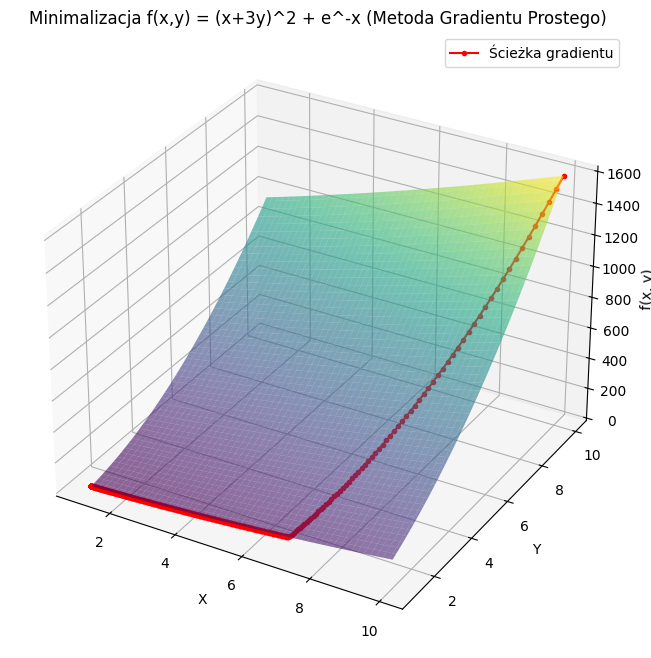



ZADANIE 2: Obliczanie Gradientów (Wsteczna Propagacja)

Obliczone gradienty dla Wariantu 5:

Gradient dW1 (Warstwa Tanh):
[[0.00193233 0.        ]
 [0.00086217 0.        ]]

Gradient dB1 (Warstwa Tanh):
[[0.00193233]
 [0.00086217]]

Gradient dW2 (Warstwa ReLU):
[[ 0.00177932 -0.00353974]]

Gradient dB2 (Warstwa ReLU):
[[-0.12499692]]

--- Koniec Skryptu ---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ******************************************************
# ******************** ZADANIE 1 ***********************
# ******************************************************

print("="*30)
print("ZADANIE 1: Minimalizacja Funkcji za Pomocą Gradientu Prostego")
print("="*30)

# Definicja funkcji i gradientu

def f(x, y):
    """Funkcja celu (Wariant 5)"""
    return (x + 3 * y)**2 + np.exp(-x)

def gradient(x, y):
    """Obliczenie wektora gradientu [df/dx, df/dy]"""
    df_dx = 2 * (x + 3 * y) - np.exp(-x)
    df_dy = 6 * (x + 3 * y)
    return np.array([df_dx, df_dy])

# Implementacja Metody Gradientu Prostego

def gradient_descent(start_point, learning_rate, n_iterations):
    """Algorytm gradientu prostego"""
    
    x_history = [start_point[0]]
    y_history = [start_point[1]]
    f_history = [f(start_point[0], start_point[1])]
    
    current_x = start_point[0]
    current_y = start_point[1]
    
    for i in range(n_iterations):
        grad = gradient(current_x, current_y)
        
        current_x = current_x - learning_rate * grad[0]
        current_y = current_y - learning_rate * grad[1]
        
        # Ograniczenie do zakresu [1; 10]
        current_x = np.clip(current_x, 1.0, 10.0)
        current_y = np.clip(current_y, 1.0, 10.0)

        x_history.append(current_x)
        y_history.append(current_y)
        f_history.append(f(current_x, current_y))
        
    return np.array(x_history), np.array(y_history), np.array(f_history)

# Uruchomienie i Wizualizacja

# Parametry
start_point = np.array([10.0, 10.0])
learning_rate = 0.001
n_iterations = 1000

x_path, y_path, z_path = gradient_descent(start_point, learning_rate, n_iterations)

# Wyniki
print(f"\nUstawienia: Start={start_point}, Rate={learning_rate}, Iter={n_iterations}")
print(f"Znalezione minimum w (x, y) = ({x_path[-1]:.4f}, {y_path[-1]:.4f})")
print(f"Wartość funkcji w minimum: {z_path[-1]:.4f}")

# Przygotowanie danych do wykresu 3D
X_surf = np.linspace(1, 10, 100)
Y_surf = np.linspace(1, 10, 100)
X_surf, Y_surf = np.meshgrid(X_surf, Y_surf)
Z_surf = f(X_surf, Y_surf)

# Wizualizacja 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X_surf, Y_surf, Z_surf, cmap='viridis', alpha=0.6)
ax.plot(x_path, y_path, z_path, color='red', marker='o', linestyle='-', markersize=3, label='Ścieżka gradientu')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title(f'Minimalizacja f(x,y) = (x+3y)^2 + e^-x (Metoda Gradientu Prostego)')
ax.legend()
plt.show()

# ******************************************************
# ******************** ZADANIE 2 ***********************
# ******************************************************

print("\n\n"+"="*30)
print("ZADANIE 2: Obliczanie Gradientów (Wsteczna Propagacja)")
print("="*30)

# Architektura i Funkcje Aktywacji

nn_architecture = [
    {"input_dim": 2, "output_dim": 2, "activation": "tanh"}, # Warstwa 1
    {"input_dim": 2, "output_dim": 1, "activation": "relu"}  # Warstwa 2
]

# Dane testowe (4 próbki, 2 cechy wejściowe)
X = np.array([[1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [0.0, 0.0]]).T # (2, 4)
Y = np.array([[1, 0, 1, 0]]) # Etykiety (1, 4)

def tanh(Z): return np.tanh(Z)
def tanh_backward(dA, Z): return dA * (1 - np.power(tanh(Z), 2))

def relu(Z): return np.maximum(0, Z)
def relu_backward(dA, Z): 
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

# Inicjalizacja Parametrów

def init_layers(nn_architecture, seed=99):
    np.random.seed(seed)
    params = {}
    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        input_dim = layer["input_dim"]
        output_dim = layer["output_dim"]
        params['W' + str(layer_idx)] = np.random.randn(output_dim, input_dim) * 0.1
        params['B' + str(layer_idx)] = np.zeros((output_dim, 1))
    return params

# --- Propagacja w Przód (Szkielet) ---

def single_layer_forward(A_prev, W_curr, B_curr, activation):
    Z_curr = np.dot(W_curr, A_prev) + B_curr
    if activation == "relu":
        A_curr = relu(Z_curr)
    elif activation == "tanh":
        A_curr = tanh(Z_curr)
    return A_curr, Z_curr

def full_forward_propagation(X, params, nn_architecture):
    cache = {'A0': X}
    A_curr = X
    for idx, layer in enumerate(nn_architecture):
        layer_idx = idx + 1
        A_prev = A_curr
        
        W_curr = params["W" + str(layer_idx)]
        B_curr = params["B" + str(layer_idx)]
        activation = layer["activation"]
        
        A_curr, Z_curr = single_layer_forward(A_prev, W_curr, B_curr, activation)
        
        cache['A' + str(layer_idx)] = A_curr
        cache['Z' + str(layer_idx)] = Z_curr
        
    return A_curr, cache

# Propagacja Wsteczna

def back_propagation(Y_hat, Y, cache, params, nn_architecture):
    """Oblicza gradienty dW i dB dla każdej warstwy (na podstawie MSE Loss)"""
    
    grads = {}
    m = Y.shape[1] 
    
    # Obliczenie pochodnej funkcji straty
    dA_prev = (2/m) * (Y_hat - Y)
    
    # Iteracja wsteczna przez warstwy
    for layer_idx_temp in range(len(nn_architecture), 0, -1):
        layer_idx = layer_idx_temp
        
        layer = nn_architecture[layer_idx - 1]
        
        # Pobieranie danych z cache i params
        Z_curr = cache['Z' + str(layer_idx)]
        A_prev = cache['A' + str(layer_idx - 1)]
        W_curr = params['W' + str(layer_idx)]
        activation = layer["activation"]

        # Obliczenie dZ
        if activation == "relu":
            dZ_curr = relu_backward(dA_prev, Z_curr)
        elif activation == "tanh":
            dZ_curr = tanh_backward(dA_prev, Z_curr)
        else:
            raise ValueError(f"Nieobsługiwana aktywacja: {activation}")
        
        # Obliczenie dW i dB
        grads['dW' + str(layer_idx)] = (1/m) * np.dot(dZ_curr, A_prev.T)
        grads['dB' + str(layer_idx)] = (1/m) * np.sum(dZ_curr, axis=1, keepdims=True)
        
        # Obliczenie dA_prev
        dA_prev = np.dot(W_curr.T, dZ_curr)

    return grads

# Inicjalizacja
params = init_layers(nn_architecture)

# Propagacja w przód (generowanie Y_hat i cache)
Y_hat, cache = full_forward_propagation(X, params, nn_architecture)

# Propagacja wsteczna (obliczenie gradientów)
grads = back_propagation(Y_hat, Y, cache, params, nn_architecture)

print("\nObliczone gradienty dla Wariantu 5:")
print("\nGradient dW1 (Warstwa Tanh):")
print(grads['dW1'])
print("\nGradient dB1 (Warstwa Tanh):")
print(grads['dB1'])
print("\nGradient dW2 (Warstwa ReLU):")
print(grads['dW2'])
print("\nGradient dB2 (Warstwa ReLU):")
print(grads['dB2'])